In [3]:
# Code cell
# importing the necessary packages
import os
import sys
import math
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from sklearn import preprocessing, model_selection

# Chooses GPU if available; otherwise CPU. Later, model and tensors are moved to this device.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)


Device: cuda


In [4]:
#my path 
data_dir = Path("./ml-latest-small")

if not data_dir.exists():
    raise FileNotFoundError(f"{data_dir} not found")

ratings_path = data_dir / "ratings.csv"
print("Ratings file:", ratings_path)
df = pd.read_csv(ratings_path)
print("Rows:", len(df))
df.head()

Ratings file: ml-latest-small\ratings.csv
Rows: 100836


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


Users: 610
Movies: 9724
Ratings distribution:
rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


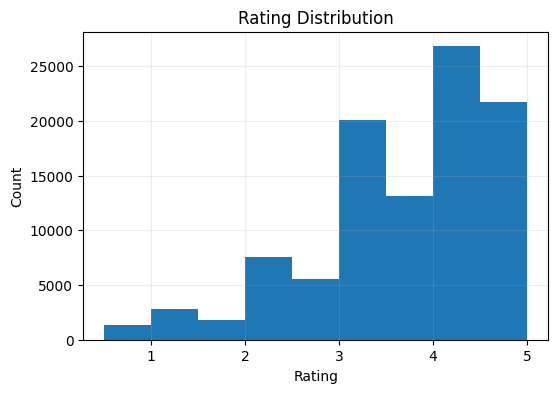

In [5]:
# Code cell
print("Users:", df.userId.nunique())
print("Movies:", df.movieId.nunique())
print("Ratings distribution:")
print(df.rating.value_counts().sort_index())

plt.figure(figsize=(6,4))
plt.hist(df.rating, bins=np.arange(0.5, 5.5, 0.5))
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Rating Distribution")
plt.grid(alpha=0.2)
plt.show()


In [6]:
# Code cell
class MovieLensDataset(Dataset):
    def __init__(self, users, movies, ratings):
        self.users = users
        self.movies = movies
        self.ratings = ratings

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        return {
            "users": torch.tensor(self.users[idx], dtype=torch.long),
            "movies": torch.tensor(self.movies[idx], dtype=torch.long),
            "ratings": torch.tensor(self.ratings[idx], dtype=torch.float32),
        }


In [7]:
# Code cell
class RecommendationModel(nn.Module):
    def __init__(self, num_users, num_movies, embedding_size=128, hidden_dim=256, dropout_rate=0.1):
        super().__init__()
        self.user_emb = nn.Embedding(num_users, embedding_size)
        self.movie_emb = nn.Embedding(num_movies, embedding_size)
        self.fc1 = nn.Linear(2 * embedding_size, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout_rate)
        self.relu = nn.ReLU()

        # init embeddings 
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.movie_emb.weight, std=0.01)

    def forward(self, users, movies):
        u = self.user_emb(users)
        m = self.movie_emb(movies)
        x = torch.cat([u, m], dim=1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        out = self.fc2(x)
        return out.squeeze(1)  # shape (batch,)


In [8]:
# Label encode user and movie ids to 0..N-1
lbl_user = preprocessing.LabelEncoder()
lbl_movie = preprocessing.LabelEncoder()
df['user_enc'] = lbl_user.fit_transform(df.userId.values)
df['movie_enc'] = lbl_movie.fit_transform(df.movieId.values)




# train-val split stratified on rating
df_train, df_val = model_selection.train_test_split(
    df, test_size=0.1, random_state=SEED, stratify=df.rating.values
)

print("Train rows:", len(df_train), "Val rows:", len(df_val))




train_dataset = MovieLensDataset(
    users=df_train.user_enc.values,
    movies=df_train.movie_enc.values,
    ratings=df_train.rating.values
)
val_dataset = MovieLensDataset(
    users=df_val.user_enc.values,
    movies=df_val.movie_enc.values,
    ratings=df_val.rating.values
)

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

num_users = len(lbl_user.classes_)
num_movies = len(lbl_movie.classes_)
print("num_users:", num_users, "num_movies:", num_movies)


Train rows: 90752 Val rows: 10084
num_users: 610 num_movies: 9724


In [9]:
# Code cell
def train_one_run(model, train_loader, optimizer, loss_fn, device, epochs=20, log_every=100):
    model.to(device)
    model.train()
    losses = []  # list of average losses logged
    step_samples = 0
    running_loss = 0.0

    total_samples = len(train_loader.dataset)
    for epoch in range(epochs):
        step_samples = 0
        running_loss = 0.0
        for i, batch in enumerate(train_loader):
            users = batch['users'].to(device)
            movies = batch['movies'].to(device)
            ratings = batch['ratings'].to(device)

            preds = model(users, movies)
            loss = loss_fn(preds, ratings)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # accumulate
            running_loss += loss.item() * users.size(0)  # sum loss over batch
            step_samples += users.size(0)

            if step_samples >= log_every:
                avg_loss = running_loss / step_samples
                losses.append(avg_loss)
                # reset counters for next logging block
                running_loss = 0.0
                step_samples = 0

        # at end of epoch, if leftover samples not logged, log them
        if step_samples > 0:
            avg_loss = running_loss / step_samples
            losses.append(avg_loss)
            running_loss = 0.0
            step_samples = 0

    return losses

def evaluate_model(model, val_loader, loss_fn, device):
    model.to(device)
    model.eval()
    total_loss = 0.0
    total_n = 0
    with torch.no_grad():
        for batch in val_loader:
            users = batch['users'].to(device)
            movies = batch['movies'].to(device)
            ratings = batch['ratings'].to(device)
            preds = model(users, movies)
            loss = loss_fn(preds, ratings)
            total_loss += loss.item() * users.size(0)
            total_n += users.size(0)
    return total_loss / total_n


Training with Feature Dimention = 128


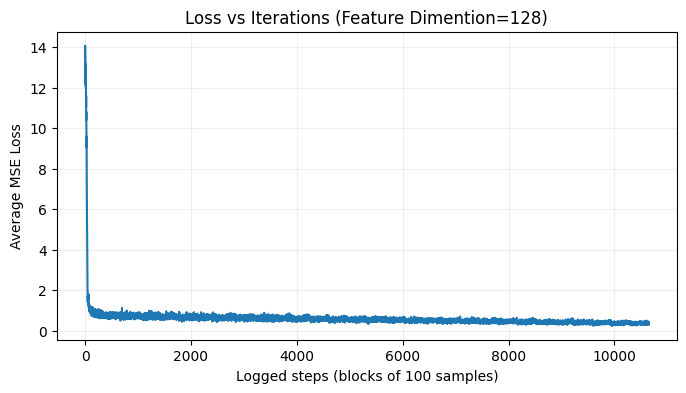

Train samples: 90752
Val samples: 10084
Batch size: 256
Logs per epoch (approx): 355
Batches per epoch (ceil): 355
Epochs configured: 30
Expected total logs approx: 10650
Expected optimizer steps (batches) per epoch: 355
Expected total optimizer steps: 10650


In [10]:
# Code cell
# Parameters for this run
embedding_size = 128        # constant n
hidden_dim = 256
dropout_rate = 0.1
lr = 1e-3
epochs = 30
log_every_samples = 100     # log average loss every these many samples

# instantiate model, optimizer, loss
model = RecommendationModel(num_users=num_users, num_movies=num_movies,
                            embedding_size=embedding_size, hidden_dim=hidden_dim,
                            dropout_rate=dropout_rate)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = nn.MSELoss(reduction='mean')

print("Training with Feature Dimention =", embedding_size)
losses_const_n = train_one_run(model, train_loader, optimizer, loss_fn, device, epochs=epochs, log_every=log_every_samples)

# save for later
np.savetxt("loss_curve_const_n.txt", np.array(losses_const_n))

# plot
plt.figure(figsize=(8,4))
plt.plot(losses_const_n)
plt.title(f"Loss vs Iterations (Feature Dimention={embedding_size})")
plt.xlabel("Logged steps (blocks of {} samples)".format(log_every_samples))
plt.ylabel("Average MSE Loss")
plt.grid(alpha=0.2)
plt.show()


num_train = len(train_loader.dataset)
num_val = len(val_loader.dataset)
batch_size = 256  # as used
logs_per_epoch = math.ceil(num_train / batch_size) if batch_size >= log_every_samples else math.ceil(num_train / log_every_samples)
print("Train samples:", num_train)
print("Val samples:", num_val)
print("Batch size:", batch_size)
print("Logs per epoch (approx):", logs_per_epoch)
print("Batches per epoch (ceil):", math.ceil(num_train / batch_size))
print("Epochs configured:", epochs)
print("Expected total logs approx:", logs_per_epoch * epochs)
print("Expected optimizer steps (batches) per epoch:", math.ceil(num_train / batch_size))
print("Expected total optimizer steps:", math.ceil(num_train / batch_size) * epochs)


In [11]:
# Code cell
emb_sizes = [32, 64, 128, 256, 512]  # 
epochs_vary = 15                     # 
lr = 1e-3
log_every_samples = 100

all_losses = {}
for emb in emb_sizes:
    print(f"\nTraining with Feature Dimention = {emb}")
    model_v = RecommendationModel(num_users=num_users, num_movies=num_movies,
                                  embedding_size=emb, hidden_dim=256, dropout_rate=0.1)
    optimizer_v = torch.optim.Adam(model_v.parameters(), lr=lr)
    losses_v = train_one_run(model_v, train_loader, optimizer_v, loss_fn, device, epochs=epochs_vary, log_every=log_every_samples)
    all_losses[emb] = losses_v
    np.savetxt(f"loss_emb_size_{emb}.txt", np.array(losses_v))




Training with Feature Dimention = 32

Training with Feature Dimention = 64

Training with Feature Dimention = 128

Training with Feature Dimention = 256

Training with Feature Dimention = 512


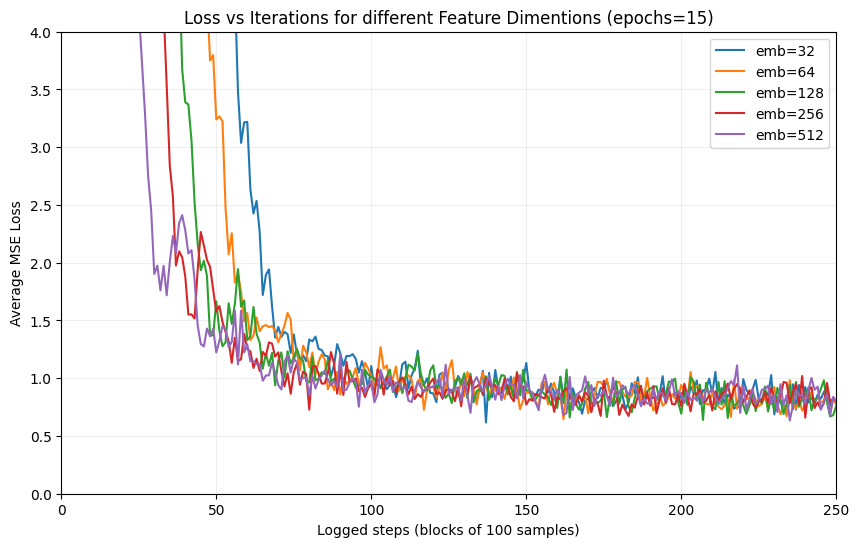

In [12]:
# Plot all on same figure
plt.figure(figsize=(10,6))
labels = []
for emb in emb_sizes:
    losses_v = all_losses[emb]
    # To align curves, plot them as-is. They may have different lengths depending on epochs and data size.
    plt.plot(losses_v, label=f"emb={emb}")
plt.xlabel("Logged steps (blocks of {} samples)".format(log_every_samples))
plt.ylabel("Average MSE Loss")
plt.title(f"Loss vs Iterations for different Feature Dimentions (epochs={epochs_vary})")
plt.ylim(0, 4)   # <-- restrict y-axis range here
plt.xlim(0, 250)  
plt.legend()
plt.grid(alpha=0.2)
plt.show()


In [13]:
# Code cell
# Evaluate the model from section 8 (model is still in memory if you didn't reassign)
try:
    val_loss = evaluate_model(model, val_loader, loss_fn, device)
    print(f"Validation MSE (model with emb={embedding_size}): {val_loss:.6f}")
except Exception as e:
    print("Couldn't evaluate model (maybe it was overwritten). Re-train or instantiate and evaluate.")


Validation MSE (model with emb=128): 0.906334


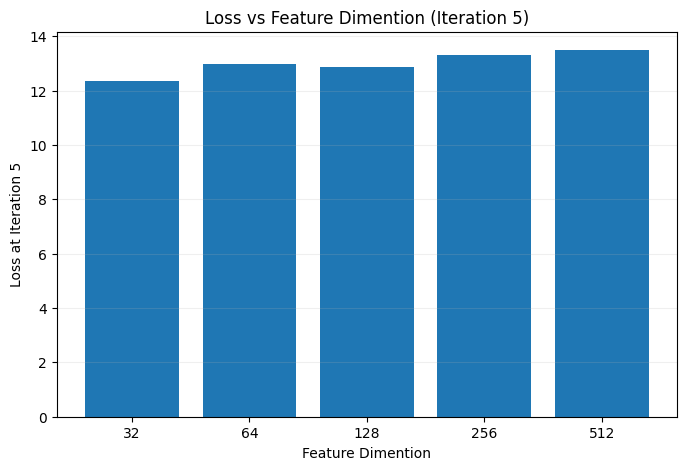

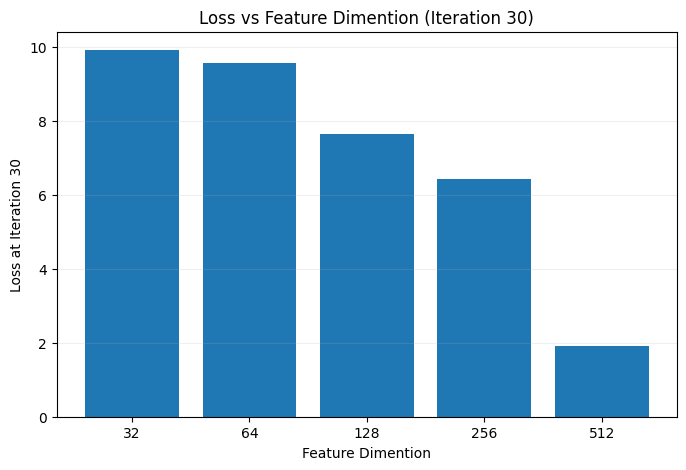

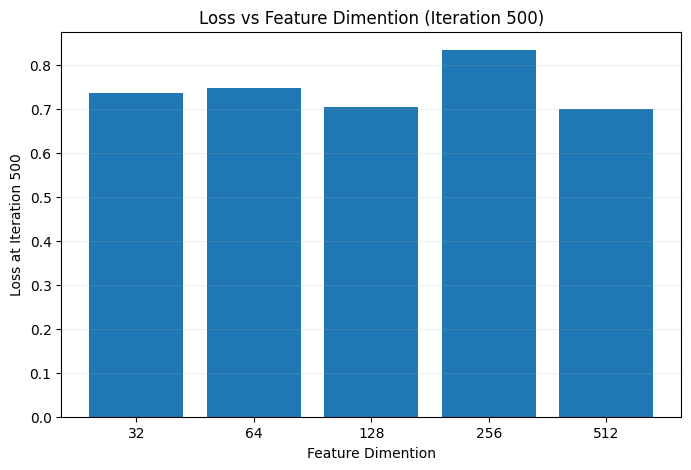

In [14]:
# Show loss vs Feature Dimention for iteration number 200 (if available)
iterations = [5,30,500]

for iteration in iterations:

    losses_at_iter = []
    embs_available = []

    for emb in emb_sizes:
        losses = all_losses[emb]
        if len(losses) > iteration:
            losses_at_iter.append(losses[iteration])
            embs_available.append(emb)

    plt.figure(figsize=(8,5))
    plt.bar([str(e) for e in embs_available], losses_at_iter)
    plt.xlabel("Feature Dimention")
    plt.ylabel(f"Loss at Iteration {iteration}")
    plt.title(f"Loss vs Feature Dimention (Iteration {iteration})")
    plt.grid(axis='y', alpha=0.2)
    plt.show()

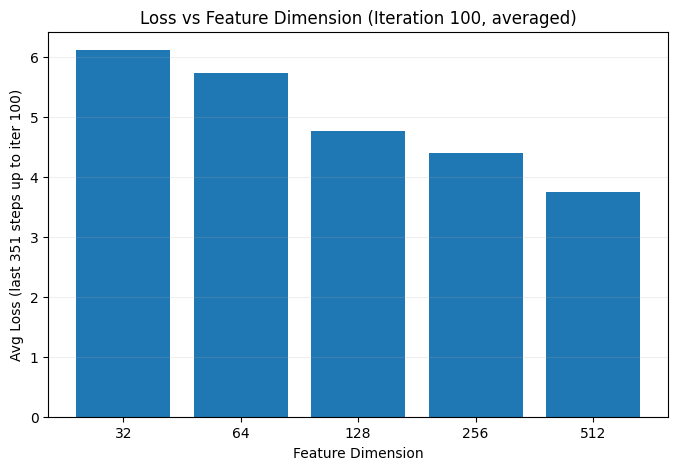

In [17]:
# Show averaged loss vs Feature Dimension for selected iteration numbers
iterations = [100]
window = 351   # average over last 50 points up to iteration

for iteration in iterations:
    losses_at_iter = []
    embs_available = []

    for emb in emb_sizes:
        losses = all_losses[emb]
        if len(losses) > iteration:
            # Define averaging window (avoid going below 0)
            start_idx = max(0, iteration - window)
            avg_loss = np.mean(losses[start_idx:iteration+1])
            losses_at_iter.append(avg_loss)
            embs_available.append(emb)

    plt.figure(figsize=(8,5))
    plt.bar([str(e) for e in embs_available], losses_at_iter)
    plt.xlabel("Feature Dimension")
    plt.ylabel(f"Avg Loss (last {window} steps up to iter {iteration})")
    plt.title(f"Loss vs Feature Dimension (Iteration {iteration}, averaged)")
    plt.grid(axis='y', alpha=0.2)
    plt.show()
